# 05_EDA: 产业园对房价影响的可视化分析

本notebook旨在将产业园对房价的影响在真实地图上可视化出来。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功")

库导入成功


## 1. 加载数据

In [2]:
# 加载产业园数据和房价数据
park_df = pd.read_csv('processed_data/01_park.csv')
housing_df = pd.read_csv('processed_data/03_data.csv')

print(f"产业园数据: {park_df.shape}")
print(f"房价数据: {housing_df.shape}")
print("\n产业园数据列:", park_df.columns.tolist())
print("\n房价数据列:", housing_df.columns.tolist()[:20], "...")

产业园数据: (103190, 3)
房价数据: (261159, 99)

产业园数据列: ['x', 'y', '产业']

房价数据列: ['城市', '区域', '板块', 'price', 'unit_price', '建筑面积', '配备电梯', '挂牌时间', '上次交易', '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份', 'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry'] ...


## 2. 数据概览

In [3]:
print("=== 产业园数据 ===")
print(park_df.head())
print("\n产业类型分布:")
print(park_df['产业'].value_counts())

=== 产业园数据 ===
            x          y    产业
0  109.408592  24.347670  汽车工业
1  115.915352  28.556732  汽车工业
2  116.032730  36.458038  汽车工业
3  113.533096  23.110100  汽车工业
4  117.202339  39.382431  汽车工业

产业类型分布:
产业
其他        92873
电子信息       2996
文化创意       1033
家电数码        849
农林牧渔        748
装备制造        713
化工日化        546
纺织服装        535
机械设备        391
建材冶金        372
大消费         311
能源电力        287
仓储物流        273
环保节能        211
医疗医药        182
轻工业         150
科技服务        133
房地产建筑       115
食品饮料         95
电子商务         84
汽车工业         64
电子产业         63
金融保险         49
航空航天         40
 电子产业        32
高新技术         31
国防科技产业        7
 高新技术         7
Name: count, dtype: int64


In [4]:
print("=== 房价数据 ===")
print(housing_df[['城市', '区域', '板块', 'x', 'y', 'price', 'unit_price']].head())
print("\n基本统计:")
print(housing_df[['price', 'unit_price']].describe())

=== 房价数据 ===
   城市  区域   板块           x          y   price  unit_price
0  北京  朝阳   国展  116.451239  39.960643  1050.0     64072.0
1  北京  顺义  后沙峪  116.555368  40.113521   779.0     46891.0
2  北京  昌平  北七家  116.420590  40.143609  2250.0     56974.0
3  北京  昌平  回龙观  116.332045  40.081334   599.0     31830.0
4  北京  东城  永定门  116.411885  39.870980   930.0     60701.0

基本统计:
               price     unit_price
count  261159.000000  261159.000000
mean      571.489052   62673.635812
std       476.812921   32657.512372
min         6.100000      95.000000
25%       295.000000   38614.000000
50%       450.000000   54767.000000
75%       688.000000   80752.000000
max     14000.000000  264841.000000


## 3. 产业园分布可视化（静态图）

In [5]:
# 按城市筛选北京数据（数据量最大）
park_beijing = park_df[(park_df['x'] > 115) & (park_df['x'] < 118) & 
                        (park_df['y'] > 39) & (park_df['y'] < 41)].copy()
housing_beijing = housing_df[housing_df['城市'] == '北京'].copy()

print(f"北京产业园数量: {len(park_beijing)}")
print(f"北京房价数据量: {len(housing_beijing)}")

北京产业园数量: 4171
北京房价数据量: 261159


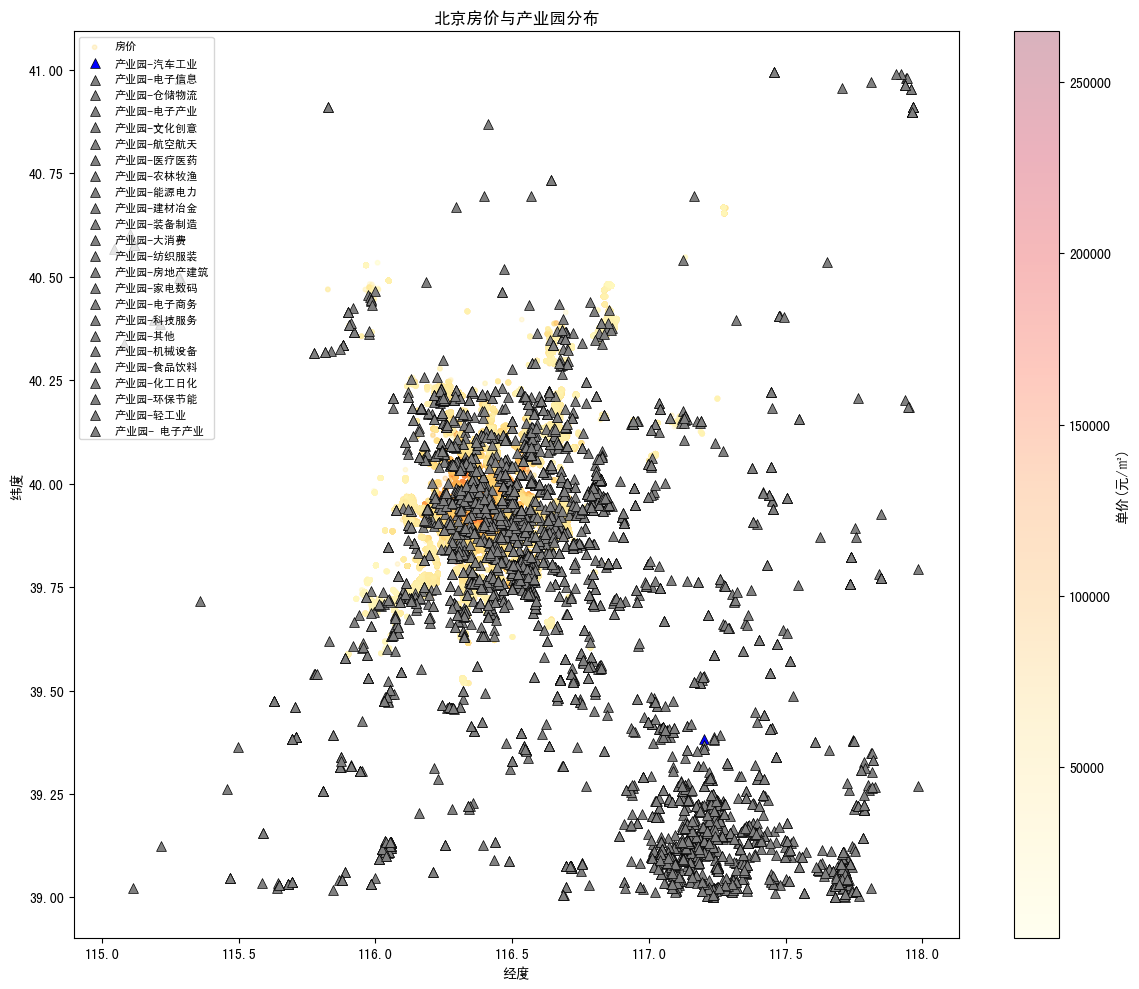

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# 绘制房价散点图（按单价着色）
scatter = ax.scatter(housing_beijing['x'], housing_beijing['y'], 
                     c=housing_beijing['unit_price'], cmap='YlOrRd', 
                     alpha=0.3, s=10, label='房价')

# 绘制产业园位置
industry_colors = {'汽车工业': 'blue', 'IT电子': 'green', '生物医药': 'purple', 
                   '金融产业': 'gold', '其他': 'gray'}
for industry in park_beijing['产业'].unique():
    subset = park_beijing[park_beijing['产业'] == industry]
    color = industry_colors.get(industry, 'gray')
    ax.scatter(subset['x'], subset['y'], c=color, marker='^', s=50, 
              edgecolors='black', linewidth=0.5, label=f'产业园-{industry}')

ax.set_xlabel('经度')
ax.set_ylabel('纬度')
ax.set_title('北京房价与产业园分布')
ax.legend(loc='upper left', fontsize=8)
plt.colorbar(scatter, label='单价(元/㎡)')
plt.tight_layout()
plt.show()

## 4. 交互式地图可视化 (Folium)

In [7]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# 创建底图（北京中心）
center_lat = housing_beijing['y'].mean()
center_lon = housing_beijing['x'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

print(f"地图中心: ({center_lat:.4f}, {center_lon:.4f})")

地图中心: (39.9440, 116.4232)


In [8]:
# 添加房价热力图
housing_sample = housing_beijing.sample(min(5000, len(housing_beijing)), random_state=42)
heat_data = [[row['y'], row['x'], row['unit_price']] for _, row in housing_sample.iterrows()]
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(m)

# 添加产业园标记（不同颜色代表不同产业类型）
industry_colors_map = {
    '汽车工业': 'blue',
    'IT电子': 'darkgreen', 
    '生物医药': 'darkpurple',
    '金融产业': 'orange',
    '其他': 'gray'
}

for _, row in park_beijing.iterrows():
    color = industry_colors_map.get(row['产业'], 'gray')
    folium.Marker(
        location=[row['y'], row['x']],
        popup=f"产业: {row['产业']}",
        icon=folium.Icon(color=color, icon='info-sign')
    ).add_to(m)

print("热力图和产业园标记已添加")

热力图和产业园标记已添加


In [9]:
# 保存交互式地图
m.save('park_housing_heatmap.html')
print("交互式地图已保存至: park_housing_heatmap.html")
# 在notebook中显示
m

交互式地图已保存至: park_housing_heatmap.html


## 5. 产业园周边房价分析

In [10]:
# 按最近产业园产业类型分组统计房价
print("=== 不同产业类型周边的房价统计 ===")
industry_price_stats = housing_beijing.groupby('nearest_park_industry')['unit_price'].agg(['mean', 'median', 'std', 'count'])
industry_price_stats = industry_price_stats.sort_values('mean', ascending=False)
print(industry_price_stats)

=== 不同产业类型周边的房价统计 ===
                                mean    median           std   count
nearest_park_industry                                               
环保节能                   102958.113004  102141.0  21285.543315    1115
机械设备                    74852.178108   73768.0  23142.225708     539
建材冶金                    72584.541880   61488.0  33866.284074    2340
装备制造                    71190.444828   63606.5  24986.023384     580
汽车工业                    70040.096774   69188.0  10601.306346     186
电子信息                    69436.202112   61220.0  32588.529406   31537
大消费                     68698.650495   62786.0  32561.039141    4246
文化创意                    67452.638118   57481.0  34719.850967    8033
家电数码                    65512.071332   62828.0  23859.412504    4416
其他                      61540.583908   53155.5  32655.810616  200482
电子商务                    59437.571429   59900.5   3736.873257      28
医疗医药                    56716.367774   39902.0  30013.541068     813
纺织服装        

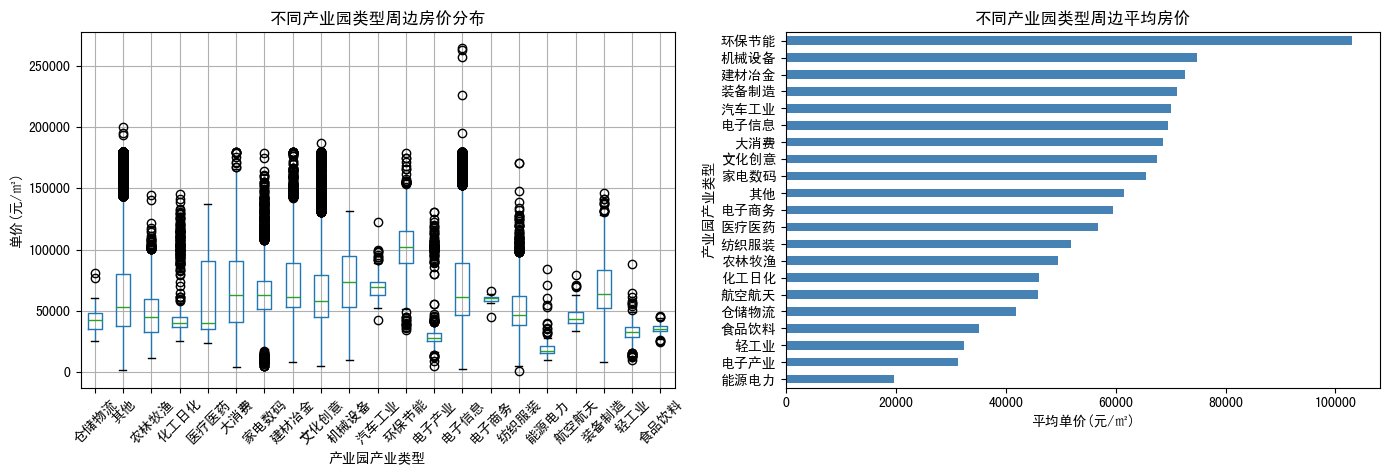

In [11]:
# 可视化：不同产业类型周边的房价分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 箱线图
housing_beijing.boxplot(column='unit_price', by='nearest_park_industry', ax=axes[0])
axes[0].set_title('不同产业园类型周边房价分布')
axes[0].set_xlabel('产业园产业类型')
axes[0].set_ylabel('单价(元/㎡)')
plt.sca(axes[0])
plt.xticks(rotation=45)

# 条形图 - 平均单价
industry_mean = housing_beijing.groupby('nearest_park_industry')['unit_price'].mean().sort_values(ascending=True)
industry_mean.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('不同产业园类型周边平均房价')
axes[1].set_xlabel('平均单价(元/㎡)')
axes[1].set_ylabel('产业园产业类型')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. 距离与房价关系分析

In [12]:
housing_beijing.columns

Index(['城市', '区域', '板块', 'price', 'unit_price', '建筑面积', '配备电梯', '挂牌时间', '上次交易',
       '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份',
       'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry',
       'log_price', 'log_unit_price', 'area', 'distance_to_center', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_

In [13]:
# 创建距离区间
housing_beijing['dist_bin'] = pd.cut(housing_beijing['nearest_park_dist_km'], 
                                     bins=[0, 1, 2, 5, 10, 20, 50],
                                     labels=['0-1km', '1-2km', '2-5km', '5-10km', '10-20km', '20-50km'])

print("=== 不同距离区间的房价统计 ===")
dist_price_stats = housing_beijing.groupby('dist_bin')['unit_price'].agg(['mean', 'median', 'count'])
print(dist_price_stats)

=== 不同距离区间的房价统计 ===
                  mean   median   count
dist_bin                               
0-1km     65824.031691  58253.0  211131
1-2km     51533.284183  44518.5   44700
2-5km     33686.466100  34390.0    4351
5-10km    19715.027778  18737.0     252
10-20km   20985.677241  20611.0     725
20-50km            NaN      NaN       0


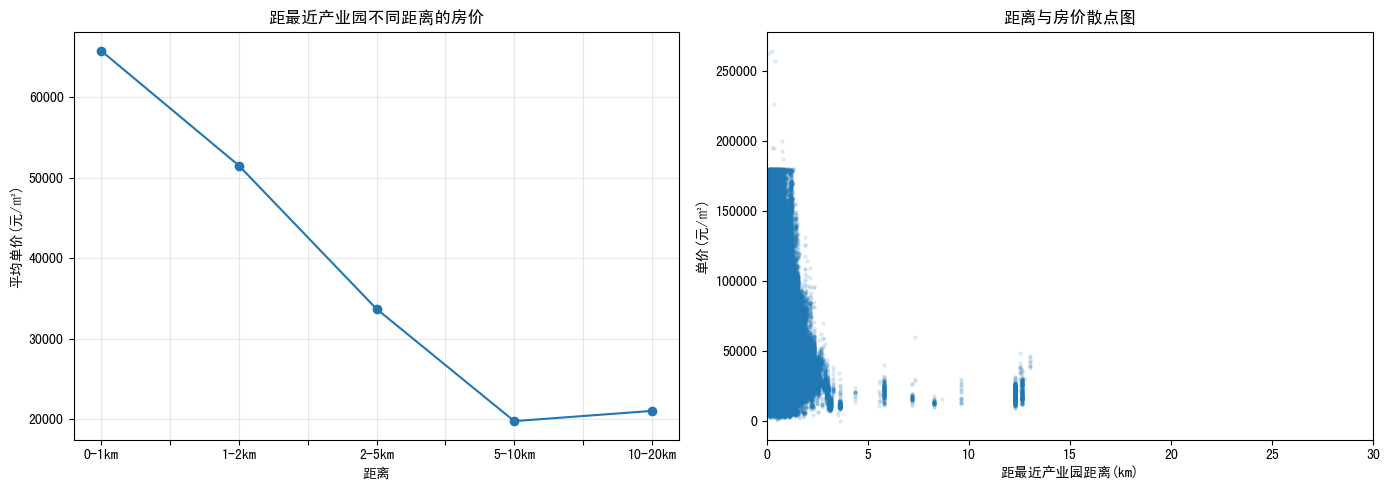

In [14]:
# 可视化：距离与房价的关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 折线图
dist_means = housing_beijing.groupby('dist_bin')['unit_price'].mean()
dist_means.plot(marker='o', ax=axes[0])
axes[0].set_title('距最近产业园不同距离的房价')
axes[0].set_xlabel('距离')
axes[0].set_ylabel('平均单价(元/㎡)')
axes[0].grid(True, alpha=0.3)

# 散点图
axes[1].scatter(housing_beijing['nearest_park_dist_km'], 
               housing_beijing['unit_price'], alpha=0.1, s=5)
axes[1].set_title('距离与房价散点图')
axes[1].set_xlabel('距最近产业园距离(km)')
axes[1].set_ylabel('单价(元/㎡)')
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.show()

## 7. 多产业类型对比地图

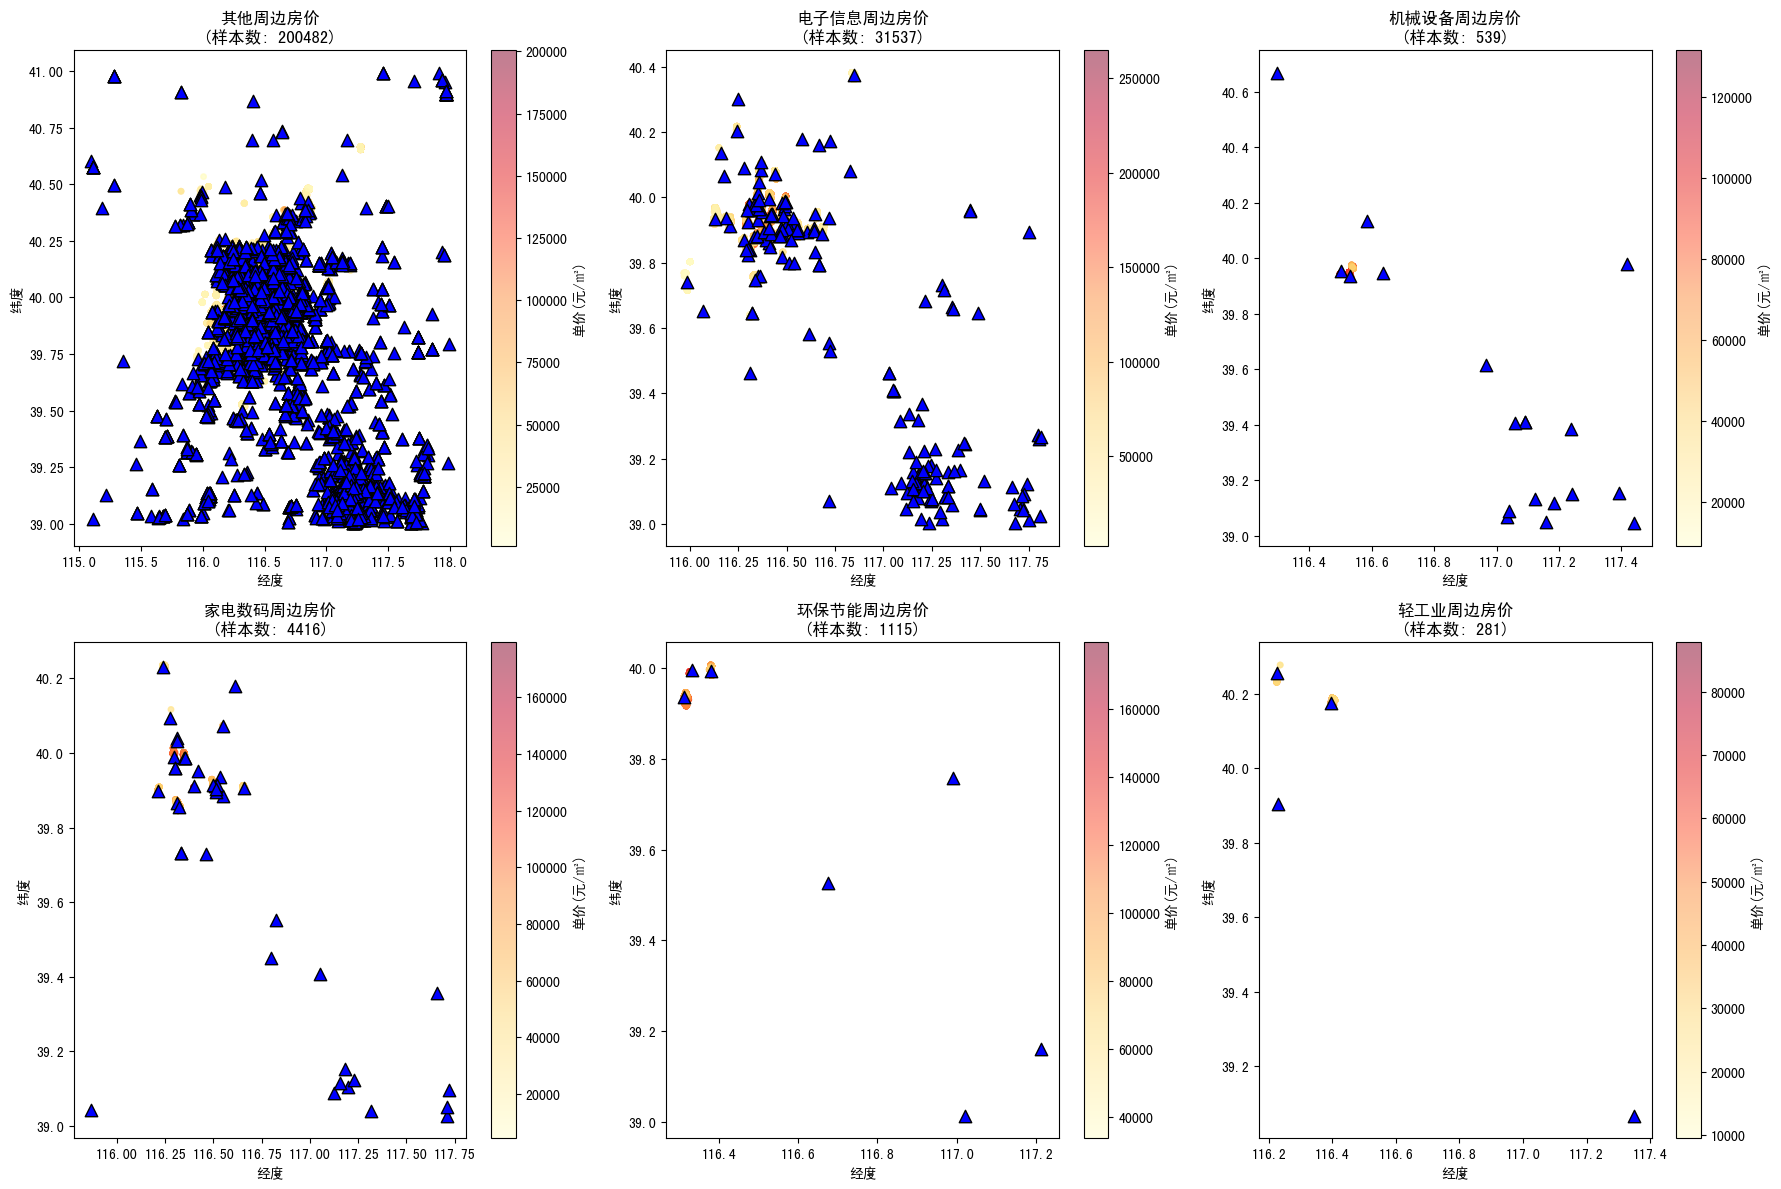

In [17]:
# 创建对比地图：不同产业类型周边房价热力图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

industries = housing_beijing['nearest_park_industry'].unique()[:6]

for idx, industry in enumerate(industries):
    ax = axes[idx]
    subset = housing_beijing[housing_beijing['nearest_park_industry'] == industry]
    
    # 绘制该产业周边的房价
    scatter = ax.scatter(subset['x'], subset['y'], 
                        c=subset['unit_price'], cmap='YlOrRd', 
                        alpha=0.5, s=15)
    
    # 标注该产业的产业园位置
    park_subset = park_beijing[park_beijing['产业'] == industry]
    ax.scatter(park_subset['x'], park_subset['y'], 
              c='blue', marker='^', s=80, edgecolors='black')
    
    ax.set_title(f'{industry}周边房价\n(样本数: {len(subset)})')
    ax.set_xlabel('经度')
    ax.set_ylabel('纬度')
    plt.colorbar(scatter, ax=ax, label='单价(元/㎡)')

plt.tight_layout()
plt.show()

## 8. 总结

In [18]:
print("=" * 60)
print("分析总结")
print("=" * 60)

print("\n1. 产业园周边房价统计:")
print(industry_price_stats)

print("\n2. 距离与房价关系:")
print(dist_price_stats)

# 计算相关性
corr = housing_beijing['nearest_park_dist_km'].corr(housing_beijing['unit_price'])
print(f"\n3. 距离与单价相关系数: {corr:.4f}")
print("   (负相关表示距离产业园越近房价越高)")

分析总结

1. 产业园周边房价统计:
                                mean    median           std   count
nearest_park_industry                                               
环保节能                   102958.113004  102141.0  21285.543315    1115
机械设备                    74852.178108   73768.0  23142.225708     539
建材冶金                    72584.541880   61488.0  33866.284074    2340
装备制造                    71190.444828   63606.5  24986.023384     580
汽车工业                    70040.096774   69188.0  10601.306346     186
电子信息                    69436.202112   61220.0  32588.529406   31537
大消费                     68698.650495   62786.0  32561.039141    4246
文化创意                    67452.638118   57481.0  34719.850967    8033
家电数码                    65512.071332   62828.0  23859.412504    4416
其他                      61540.583908   53155.5  32655.810616  200482
电子商务                    59437.571429   59900.5   3736.873257      28
医疗医药                    56716.367774   39902.0  30013.541068     813
纺织服装          

In [19]:
# 保存处理后的数据
housing_beijing.to_csv('processed_data/05_eda_beijing.csv', index=False)
print("\n处理后的北京数据已保存至: processed_data/05_eda_beijing.csv")


处理后的北京数据已保存至: processed_data/05_eda_beijing.csv
